# Constraint cosmological parameters and cosmic baryons

In [9]:
import sys
sys.path.append('../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

# Show data

In [10]:
data=pd.read_csv('../Data/FRB.csv')
data

,FRB,z,DM,DM_ext,From
0,FRB 20180814A,0.06800,190.900,73.30,Fan
1,FRB 20181030A,0.00385,103.396,32.30,Fan
2,FRB 20220529A,0.18390,246.000,176.00,Fan
3,FRB 20220610A,1.01600,1458.150,1397.15,Fan
4,FRB 20220717A,0.36295,637.340,489.04,Fan
...,...,...,...,...,...
112,FRB 20231204A,0.06440,221.000,159.94,CHIME2025
113,FRB 20231206A,0.06590,457.700,370.12,CHIME2025
114,FRB 20231223C,0.10590,165.800,87.07,CHIME2025
115,FRB 20231229A,0.01900,198.500,110.98,CHIME2025


In [11]:
print(len(data))
data = data[data['FRB'] != 'FRB 20190520B']
data = data[data['FRB'] != 'FRB 20220831A']
data = data[data['z'] >= 0.2]
# data = data[data['FRB'] == 'FRB 20230521B']
print(len(data))
data.head()

117
56


,FRB,z,DM,DM_ext,From
3,FRB 20220610A,1.01600,1458.15,1397.15,Fan
4,FRB 20220717A,0.36295,637.34,489.04,Fan
6,FRB 20230521B,1.35400,1342.90,1174.10,Fan
7,FRB 20230814A,0.55300,696.40,561.60,Fan
8,FRB 20231220A,0.33550,491.20,411.30,Fan


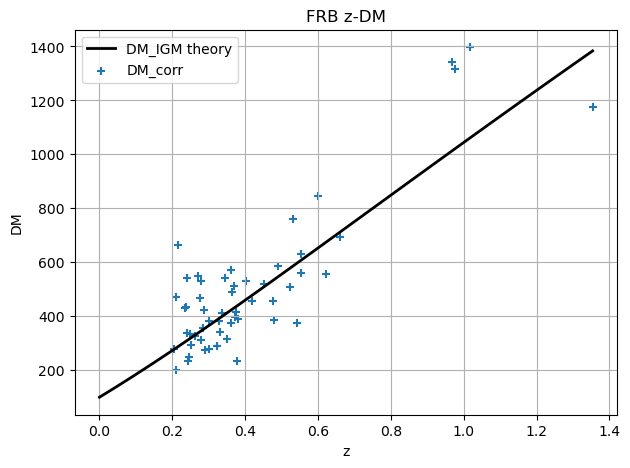

In [12]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0, np.max(data['z']), 100)

DM_theory = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)

ax1.plot(z_range, 100+DM_theory, lw=2, c='black', label='DM_IGM theory')
ax1.scatter(data['z'], data['DM_ext'], s=40, marker='+', label='DM_corr')  
ax1.set_xlabel('z')
ax1.set_ylabel('DM')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

# Preparation interpolation

In [13]:
Sigmas=np.load('./interpolation/sigmas.npy')
Vars_sqrt=np.load('./interpolation/Vars_sqrt.npy')
C0s=np.load('./interpolation/C0s.npy')
As=np.load('./interpolation/As.npy')

In [14]:
sigma_var = interpolate.interp1d(Vars_sqrt, Sigmas, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [15]:
C0_sigma = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [16]:
A_sigma = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

Text(0, 0.5, 'Sigma')

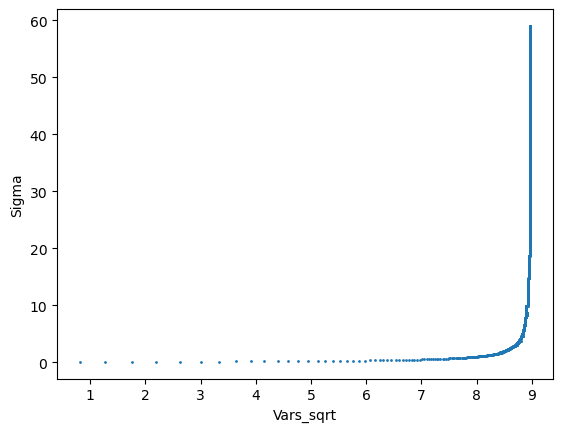

In [17]:
plt.scatter(Vars_sqrt, Sigmas,s=1)
plt.xlabel('Vars_sqrt')
plt.ylabel('Sigma')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


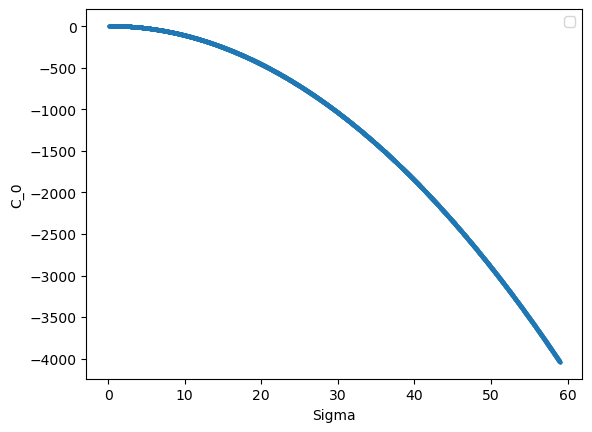

In [18]:
plt.scatter(Sigmas, C0s,  s=3)

plt.ylabel('C_0')
plt.xlabel('Sigma')
plt.legend()

plt.show()

In [19]:
sigmas=[sigma_var(np.sqrt(var_min)),sigma_var(np.sqrt(var_max))]
sigma_min=np.min(sigmas)
sigma_max=np.max(sigmas)
print([sigma_min,sigma_max])

[0.1160519079564, 3.4578399477306196]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


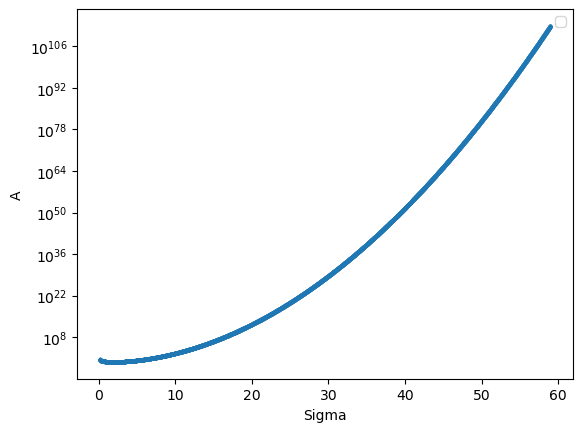

In [20]:
plt.scatter(Sigmas, As,  s=3)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
plt.legend()

plt.show()

# MCMC

Constrain $H_0 \Omega_0 f_{IGM}=const $

In [21]:
def DM_IGM_H0_O_b_f_IGM(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z, Om, w):
        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    integral, _ = quad(integrand, 0, z, args=(Om, w))
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [22]:
def DM_IGM_H0_O_b_f_IGM_fast(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z):
        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    zs=np.linspace(0, z, 5000)
    dms=integrand(zs)
    integral=np.trapz(dms, x=zs)
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [23]:
z=2.00
print(DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HUBBLE*OMEGA_BARYONS*f_IGM))
print(DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HUBBLE*OMEGA_BARYONS*f_IGM))

1783.9271709534178
1783.9271636954275


In [24]:
def calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=C0_sigma(sigma)
    A = A_sigma(sigma)
    
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [25]:
def calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    # print([f_variance_delta(F,z),sigma,C_0, A])
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [26]:
# def calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
#     DM_host_array = np.linspace(0.01, DM_frb_max * (1+z)-0.01, 5000)

#     ## Host calculation
#     pdf_host = pdf_DM_host(DM_host_array, e_mu, sigma_host)
    
#     ## Cosmic calculation    
#     DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
#     Deltas = (DM_frb_max-DM_host_array/(1+z))/DM_th
#     C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s,sigma_met="Mac")
#     A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3,sigma_met="Mac")
#     pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z), met="Mac")
    
#     ## Combine together    
#     prob = np.trapz(pdf_host*pdf_cosmic, x=DM_host_array)
    
#     ## Transform to probabilities
#     # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
#     return prob/DM_th

In [27]:
def calculate_dm_probability_num_HOf_v3(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0, DM_frb_max / DM_th, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    p_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    p_cosmic[np.isnan(p_cosmic)] = 0
    
    # print([f_variance_delta(F,z),sigma,C_0, A])
    
    ## Host calculation
    p_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    p_host[np.isnan(p_host)] = 0
    
    ## Combine together    
    prob = np.trapz(p_host*p_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [29]:
DM_frb_max=1174.1
z=1.354
F=10
HOf=3.0
e_mu=200
sigma_host=0.6

# print(calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host))
# print(calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host))
# print(calculate_dm_probability_num_HOf_v3(DM_frb_max, z, F, HOf, e_mu, sigma_host))
print(calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host))

0.001196427174876296


In [30]:
import emcee
from multiprocessing import Pool

def log_prior(theta):
    """
    Calculate the log of the prior probability for a set of parameters.
    
    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
    
    Returns:
        Log prior probability
    """
    F, HOf, sigma_host, e_mu = theta
    
    # Define your prior ranges here
    F_min, F_max = 0.1, 18  # Example range, adjust based on your model
    HOf_min, HOf_max = 1.0, 5.0  # Example range, adjust based on your model
    sigma_host_min, sigma_host_max = 0.2,1.4  # Example range
    e_mu_min, e_mu_max = 50, 300  # Example range
    
    # Check if parameters are within prior ranges
    if (F_min <= F <= F_max and 
        HOf_min <= HOf <= HOf_max and 
        sigma_host_min <= sigma_host <= sigma_host_max and 
        e_mu_min <= e_mu <= e_mu_max):
        return 0.0  # Log(1) = 0, flat prior
    else:
        return -np.inf  # Log(0) = -inf, outside prior range

def log_likelihood(theta, data):
    """
    Calculate the log likelihood for a set of parameters given the data.
    
    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
        data: Pandas DataFrame containing FRB data
    
    Returns:
        Log likelihood
    """
    F, HOf, sigma_host, e_mu = theta
    
    log_like = 0.0
    
    try:
        for _, row in data.iterrows():
            prob = calculate_dm_probability_num_HOf_fast(
                DM_frb_max=row['DM_ext'],
                z=row['z'],
                F=F,
                HOf=HOf,
                sigma_host=sigma_host,
                e_mu=e_mu
            )
            
            if prob > 0:
                log_like += np.log(prob)
            else:
                return -np.inf
        
        return log_like
    except Exception as e:
        print(f"Error in log_likelihood: {e} with parameters {theta}")
        return -np.inf

def log_probability(theta, data):
    """
    Calculate the log probability (posterior) for a set of parameters.
    
    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
        data: Pandas DataFrame containing FRB data
    
    Returns:
        Log posterior probability
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    
    ll = log_likelihood(theta, data)
    if not np.isfinite(ll):
        return -np.inf
    
    return lp + ll

def run_mcmc(data, initial_params, nwalkers=32, heating=1000, nsteps=10000, ndim=4):
    """
    Run the MCMC analysis.
    
    Args:
        data: Pandas DataFrame containing FRB data
        initial_params: Initial parameter values [F, HOf, sigma_host, e_mu]
        nwalkers: Number of walkers
        nsteps: Number of steps per walker
        ndim: Number of dimensions (parameters)
    
    Returns:
        sampler: emcee sampler object with results
    """
    # Set initial positions with small random offsets
    pos = initial_params + 0.1 * np.random.randn(nwalkers, ndim)
    # pos = [initial_params + _*1e-2 * np.random.randn(ndim) for _ in range(nwalkers)]
    
    for i in range(nwalkers):
        while log_prior(pos[i]) == -np.inf:
            pos[i] = initial_params + 0.1 * np.random.randn(ndim)
    
    # Set up the sampler
    with Pool() as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers, ndim, log_probability, 
            args=(data,), pool=pool,
            moves=[(emcee.moves.DEMove(), 0.8),
                   (emcee.moves.DESnookerMove(), 0.2)]
        )
        
        # Run the MCMC
        print("Running MCMC...")
        
        print("heating...")
        state = None
        with tqdm(total=heating) as pbar:
            for i, result in enumerate(sampler.sample(pos, iterations=heating)):
                pbar.update(1)
                state = result
                if i % 100 == 0:
                    # Calculate acceptance fraction periodically
                    acc_frac = np.mean(sampler.acceptance_fraction)
                    pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
    
        print("main running...")
        with tqdm(total=nsteps) as pbar:
            for i, result in enumerate(sampler.sample(state.coords, iterations=nsteps)):
                pbar.update(1)
                
                # check acceptance fraction
                if i % 100 == 0:
                    acc_frac = np.mean(sampler.acceptance_fraction)
                    pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
                    
                    # if acceptance fraction always = 0，reset initial parameters
                    if i > 500 and acc_frac < 0.001:
                        print("warning: acceptance fraction too low，reset parameters or resun MCMC")
    
    # check acceptance fraction
    final_acc_frac = np.mean(sampler.acceptance_fraction)
    print(f"final acceptance fraction: {final_acc_frac:.3f}")
    
    if final_acc_frac < 0.01:
        print("warning: acceptance fraction too low，reset parameters or resun MCMC")
    
    return sampler

def analyze_results(sampler, burn_in=1000, thin=15):
    """
    Analyze the MCMC results.
    
    Args:
        sampler: emcee sampler with results
        burn_in: Number of initial steps to discard
        thin: Thinning factor for samples
    
    Returns:
        samples: Flattened, burned-in, and thinned samples
        params_median: Median parameter values
        params_errors: Parameter uncertainties (16th and 84th percentiles)
    """
    # Discard burn-in, flatten and thin the samples
    flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
    
    # Calculate the median and 16th and 84th percentiles for the parameters
    params_median = np.median(flat_samples, axis=0)
    params_lower = np.percentile(flat_samples, 16, axis=0)
    params_upper = np.percentile(flat_samples, 84, axis=0)
    
    # Calculate errors
    params_errors = [(params_upper[i] - params_lower[i]) / 2 for i in range(len(params_median))]
    
    return flat_samples, params_median, params_errors

def plot_results(samples, param_names=['F', 'HOf', 'sigma_host', 'e_mu']):
    """
    Plot the MCMC results.
    
    Args:
        samples: MCMC samples
        param_names: Names of the parameters
    """
    import corner
    
    # Create corner plot
    fig = corner.corner(
        samples, 
        labels=param_names,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        title_fmt='.3f'
    )
    
    # plt.savefig("mcmc_corner_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Plot chains for each parameter
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    
    for i, (ax, name) in enumerate(zip(axes, param_names)):
        ax.plot(samples[:, i], 'k-', alpha=0.3)
        ax.set_ylabel(name)
        if i == 3:
            ax.set_xlabel("Sample Number")
    
    plt.tight_layout()
    plt.show()
    # plt.savefig("mcmc_chains.png", dpi=300)
    plt.close()

In [31]:
# Main execution
if __name__ == "__main__":
    # Load your data
    # data = pd.read_csv('your_frb_data.csv')  # Replace with your data file
    
    # Define initial parameters: [F, HOf, sigma_host, e_mu]
    initial_params = np.array([10, 3.0, 0.8, 150])  # Adjust based on your model
    
    # Run MCMC
    sampler = run_mcmc(data, initial_params, nwalkers=32, nsteps=10000)
    
    # Analyze results
    samples, params_median, params_errors = analyze_results(sampler)
    
    # Print results
    param_names = ['F', 'HOf', 'sigma_host', 'e_mu']
    print("\nMCMC Results:")
    for i, name in enumerate(param_names):
        print(f"{name} = {params_median[i]:.3f} ± {params_errors[i]:.3f}")
    
    # Plot results
    # plot_results(samples, param_names)
    
    # Save samples to file for later analysis if needed
    np.save('./posterior/mcmc_samples.npy', samples)
    
    print("\nMCMC analysis complete!")

Running MCMC...
heating...


Acceptance fraction: 0.562:   5%|▍         | 49/1000 [00:06<02:08,  7.43it/s]


KeyboardInterrupt: 

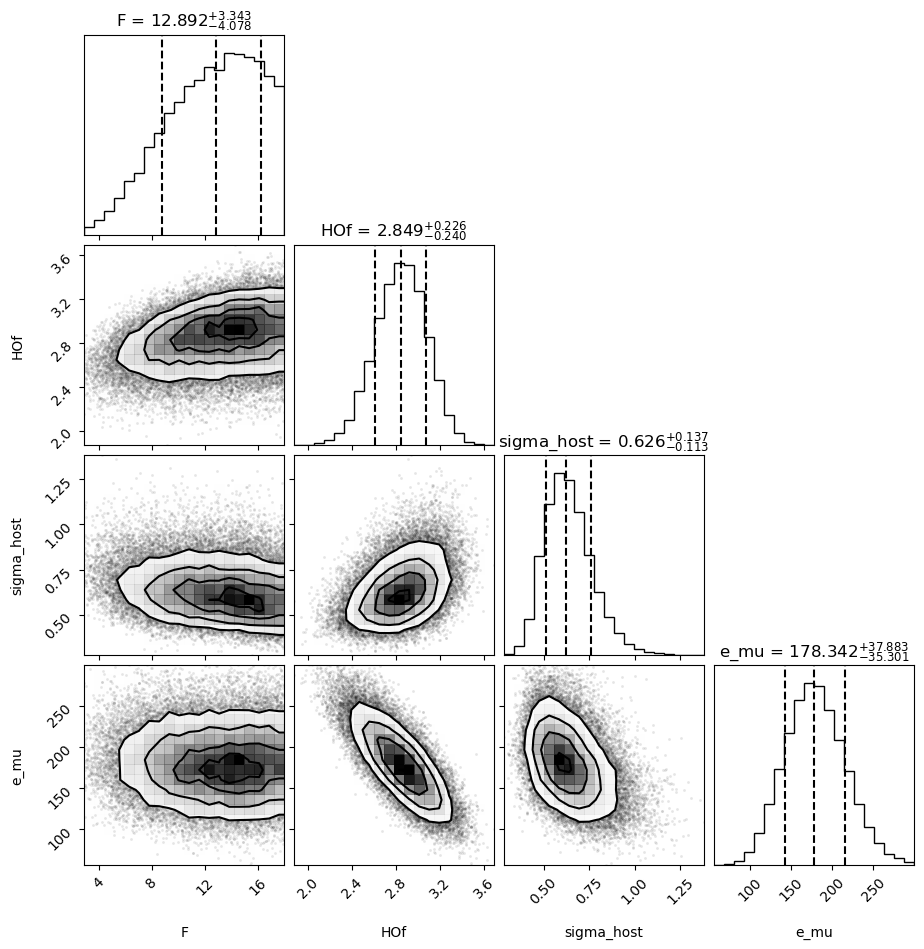

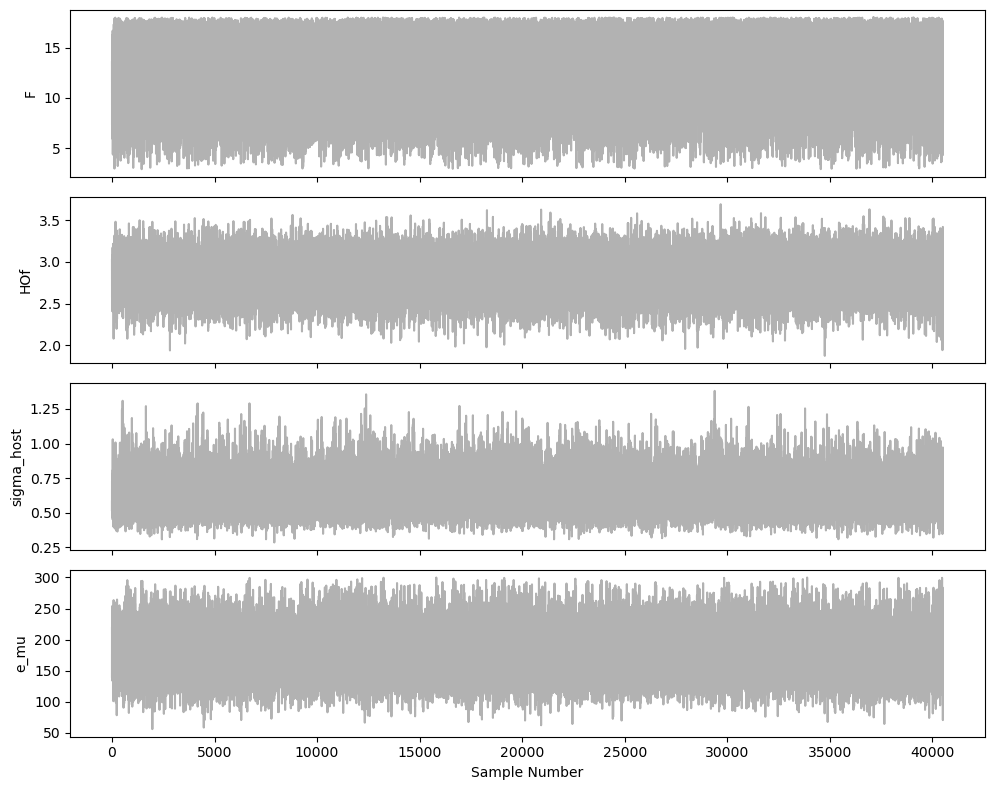

In [70]:
plot_results(samples, param_names)

In [22]:
HOf_fiducial=70*OMEGA_BARYONS*0.9
print(HOf_fiducial)

3.0851100000000002


Constrain $H_0 \Omega_0 f_{IGM}=H_0 \Omega_0 f_{IGM,0}(1+a
\cdot z)$

In [17]:
def DM_IGM_H0_O_b_f_IGM_linear_fast(z, H0_O_b_f_IGM, a, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z):
        return (1+a*z)*(1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    zs=np.linspace(0, z, 5000)
    dms=integrand(zs)
    integral=np.trapz(dms, x=zs)
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [18]:
def calculate_dm_probability_num_HOf_linear_fast(DM_frb_max, z, F, HOf, a, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_linear_fast(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=C0_sigma(sigma)
    A = A_sigma(sigma)
    
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [19]:
def calculate_dm_probability_num_HOf_linear_v2(DM_frb_max, z, F, HOf, a ,e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_linear(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(f_variance_delta(F,z))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [ ]:
import emcee
from multiprocessing import Pool

def log_prior(theta):
    """
    Calculate the log of the prior probability for a set of parameters.
    
    Args:
        theta: Array of parameters [F, HOf, a, sigma_host, e_mu]
    
    Returns:
        Log prior probability
    """
    F, HOf, a, sigma_host, e_mu = theta
    
    # Define your prior ranges here
    F_min, F_max = 0.1, 18
    HOf_min, HOf_max = 1.0, 5.0
    a_min, a_max = 0, 0.5
    sigma_host_min, sigma_host_max = 0.2,1.4
    e_mu_min, e_mu_max = 50, 300
    
    # Check if parameters are within prior ranges
    if (F_min <= F <= F_max and 
        HOf_min <= HOf <= HOf_max and 
        a_min <= a <= a_max and
        sigma_host_min <= sigma_host <= sigma_host_max and 
        e_mu_min <= e_mu <= e_mu_max):
        return 0.0  # Log(1) = 0, flat prior
    else:
        return -np.inf  # Log(0) = -inf, outside prior range

def log_likelihood(theta, data):
    """
    Calculate the log likelihood for a set of parameters given the data.
    
    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
        data: Pandas DataFrame containing FRB data
    
    Returns:
        Log likelihood
    """
    F, HOf, a, sigma_host, e_mu = theta
    
    log_like = 0.0
    
    try:
        for _, row in data.iterrows():
            prob = calculate_dm_probability_num_HOf_linear_fast(
                DM_frb_max=row['DM_ext'],
                z=row['z'],
                F=F,
                HOf=HOf,
                a=a,
                sigma_host=sigma_host,
                e_mu=e_mu
            )
            
            if prob > 0:
                log_like += np.log(prob)
            else:
                return -np.inf
        
        return log_like
    except Exception as e:
        print(f"Error in log_likelihood: {e} with parameters {theta}")
        return -np.inf

def log_probability(theta, data):
    """
    Calculate the log probability (posterior) for a set of parameters.
    
    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
        data: Pandas DataFrame containing FRB data
    
    Returns:
        Log posterior probability
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    
    ll = log_likelihood(theta, data)
    if not np.isfinite(ll):
        return -np.inf
    
    return lp + ll

def run_mcmc(data, initial_params, nwalkers=32, heating=100, nsteps=10000):
    """
    Run the MCMC analysis.
    
    Args:
        data: Pandas DataFrame containing FRB data
        initial_params: Initial parameter values [F, HOf, sigma_host, e_mu]
        nwalkers: Number of walkers
        nsteps: Number of steps per walker
        ndim: Number of dimensions (parameters)
    
    Returns:
        sampler: emcee sampler object with results
    """
    ndim=len(initial_params)
    # Set initial positions with small random offsets
    pos = initial_params + 0.1 * np.random.randn(nwalkers, ndim)
    # pos = [initial_params + _*1e-2 * np.random.randn(ndim) for _ in range(nwalkers)]
    
    for i in range(nwalkers):
        while log_prior(pos[i]) == -np.inf:
            pos[i] = initial_params + 0.1 * np.random.randn(ndim)
    
    # Set up the sampler
    with Pool() as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers, ndim, log_probability, 
            args=(data,), pool=pool,
            moves=[(emcee.moves.DEMove(), 0.8),
                   (emcee.moves.DESnookerMove(), 0.2)]
        )
        
        # Run the MCMC
        print("Running MCMC...")
        
        print("heating...")
        state = None
        with tqdm(total=heating) as pbar:
            for i, result in enumerate(sampler.sample(pos, iterations=heating)):
                pbar.update(1)
                state = result
                if i % 100 == 0:
                    # Calculate acceptance fraction periodically
                    acc_frac = np.mean(sampler.acceptance_fraction)
                    pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
    
        print("main running...")
        with tqdm(total=nsteps) as pbar:
            for i, result in enumerate(sampler.sample(state.coords, iterations=nsteps)):
                pbar.update(1)
                
                # check acceptance fraction
                if i % 100 == 0:
                    acc_frac = np.mean(sampler.acceptance_fraction)
                    pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
                    
                    # if acceptance fraction always = 0，reset initial parameters
                    if i > 500 and acc_frac < 0.001:
                        print("warning: acceptance fraction too low，reset parameters or resun MCMC")
    
    # check acceptance fraction
    final_acc_frac = np.mean(sampler.acceptance_fraction)
    print(f"final acceptance fraction: {final_acc_frac:.3f}")
    
    if final_acc_frac < 0.01:
        print("warning: acceptance fraction too low，reset parameters or resun MCMC")
    
    return sampler

def analyze_results(sampler, burn_in=1000, thin=15):
    """
    Analyze the MCMC results.
    
    Args:
        sampler: emcee sampler with results
        burn_in: Number of initial steps to discard
        thin: Thinning factor for samples
    
    Returns:
        samples: Flattened, burned-in, and thinned samples
        params_median: Median parameter values
        params_errors: Parameter uncertainties (16th and 84th percentiles)
    """
    # Discard burn-in, flatten and thin the samples
    flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
    
    # Calculate the median and 16th and 84th percentiles for the parameters
    params_median = np.median(flat_samples, axis=0)
    params_lower = np.percentile(flat_samples, 16, axis=0)
    params_upper = np.percentile(flat_samples, 84, axis=0)
    
    # Calculate errors
    params_errors = [(params_upper[i] - params_lower[i]) / 2 for i in range(len(params_median))]
    
    return flat_samples, params_median, params_errors

def plot_results(samples, param_names=['F', 'HOf', 'a', 'sigma_host', 'e_mu'],bin=30):
    """
    Plot the MCMC results.
    
    Args:
        samples: MCMC samples
        param_names: Names of the parameters
    """
    import corner
    
    # Create corner plot
    fig = corner.corner(
        samples, 
        labels=param_names,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        title_fmt='.3f',
        bins=bin
    )
    
    # plt.savefig("mcmc_corner_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Plot chains for each parameter
    fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
    
    for i, (ax, name) in enumerate(zip(axes, param_names)):
        ax.plot(samples[:, i], 'k-', alpha=0.3)
        ax.set_ylabel(name)
        if i == 3:
            ax.set_xlabel("Sample Number")
    
    plt.tight_layout()
    plt.show()
    # plt.savefig("mcmc_chains.png", dpi=300)
    plt.close()

In [ ]:
# data = data[data['z'] <= 0.8]

In [ ]:
# Main execution
if __name__ == "__main__":
    # Load your data
    # data = pd.read_csv('your_frb_data.csv')  # Replace with your data file
    
    # Define initial parameters: [F, HOf, a, sigma_host, e_mu]
    initial_params = np.array([10, 3.0, 0.1, 0.8, 150])  # Adjust based on your model
    
    # Run MCMC
    sampler = run_mcmc(data, initial_params, nwalkers=32, nsteps=100000)
    
    # Analyze results
    samples, params_median, params_errors = analyze_results(sampler)
    
    # Print results
    param_names = ['F', 'HOf', 'a', 'sigma_host', 'e_mu']
    print("\nMCMC Results:")
    for i, name in enumerate(param_names):
        print(f"{name} = {params_median[i]:.3f} ± {params_errors[i]:.3f}")
    
    # Plot results
    # plot_results(samples, param_names)
    
    # Save samples to file for later analysis if needed
    np.save('./posterior/mcmc_linear.npy', samples)
    
    print("\nMCMC analysis complete!")


MCMC Results:


NameError: name 'params_median' is not defined

In [2]:
samples=np.load('./posterior/mcmc_linear.npy')

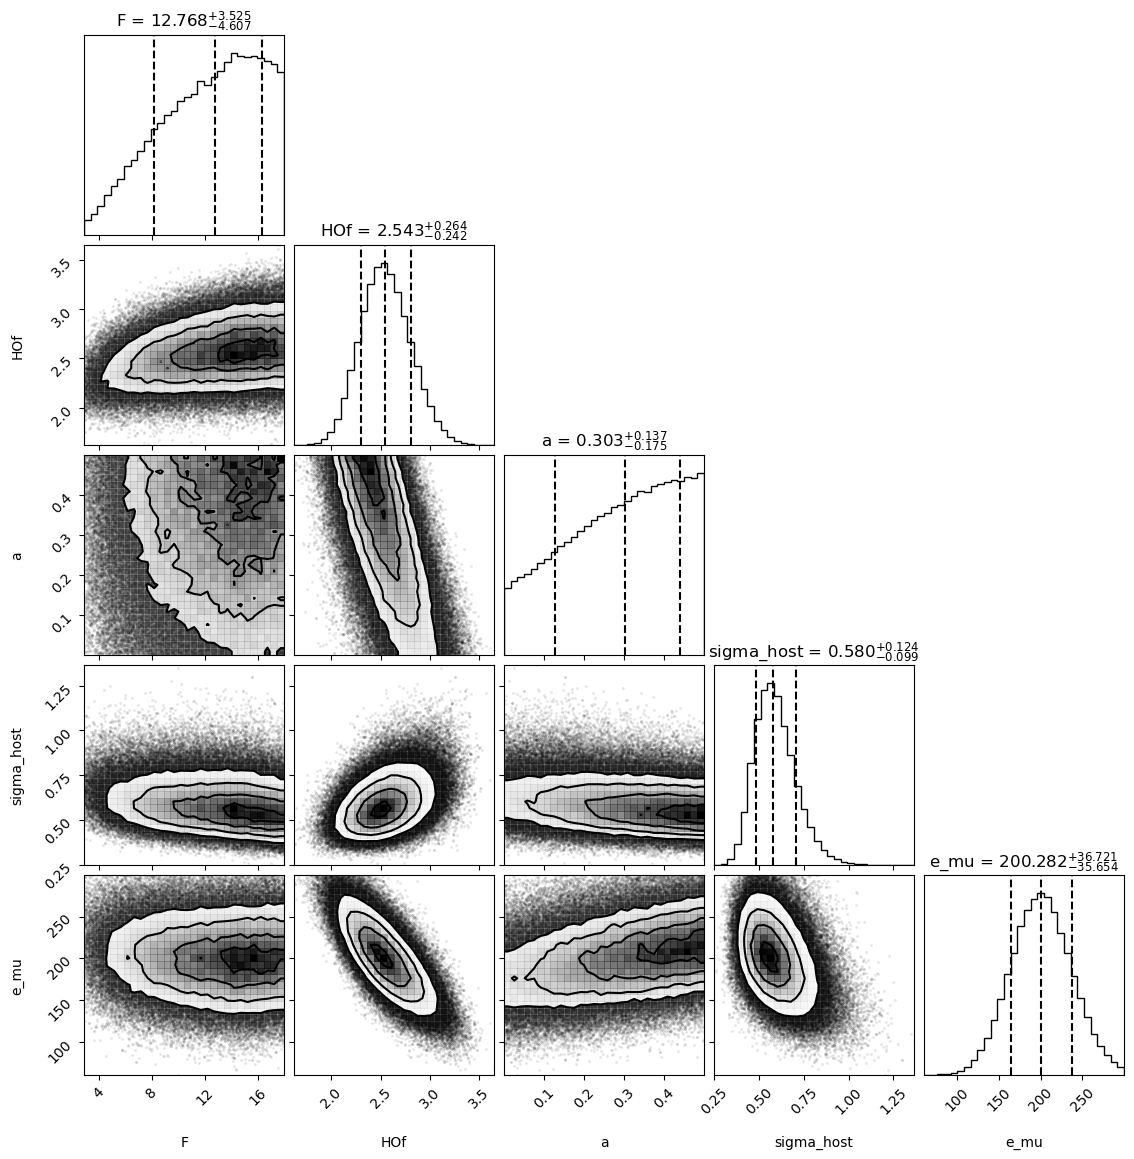

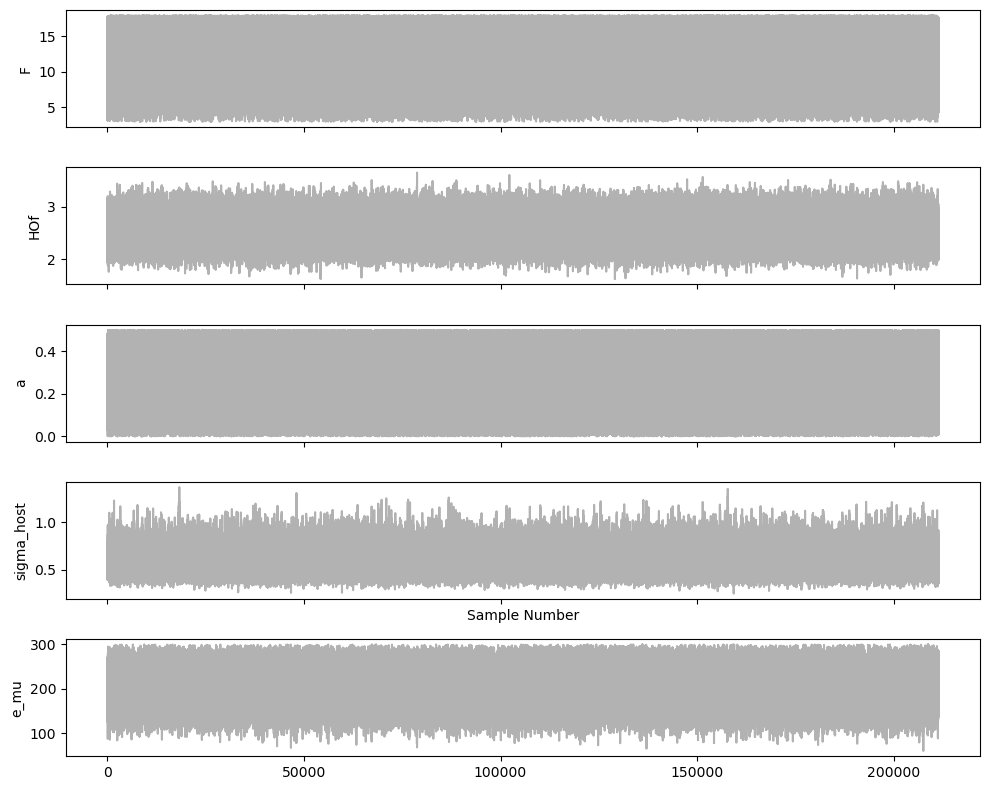

In [8]:
plot_results(samples, param_names, bin=30)